# Faster R-CNN (Tuned Run) — Torchvision Challenger Model for Food Ingredient Detection

Second training run of the torchvision Faster R-CNN challenger, implementing the changes the
baseline notebook (`fasterrcnn_food_detection.ipynb`) identified as highest-value. The dataset,
taxonomy, splits, and metrics are unchanged, so results remain directly comparable to both the
baseline run and the YOLO model.

**What is different from the baseline, and why:**

| Change | Baseline | Here | Motivation |
|---|---|---|---|
| LR schedule | `StepLR(step_size=3, gamma=0.1)` | `CosineAnnealingLR(T_max=NUM_EPOCHS)` | Baseline hit 1/100th of base LR by epoch 7; training loss flatlined for the last four epochs |
| Stopping | fixed 10 epochs | early stopping on val loss (`patience=2`) | Baseline's val loss bottomed at epoch 4; epochs 5–10 cost ~1.4 h and never improved |
| Train sampling | uniform shuffle | class-balanced `WeightedRandomSampler` | 46 of 102 evaluated classes scored exactly AP = 0 — the long tail is where the headline mAP is lost |
| Data / resolution | fixed 32.5% subset @ 512/800 | `RUN_PROFILE` selects one axis to change | Isolates the compute-budget effect from the architecture effect |
| Reporting | mAP + per-class AP | adds head/tail AP split, inference latency, baseline delta | A single average hides two very different behaviours; latency matters for a challenger framing |

Data comes from `Data/merged_yolo/`: `train.txt`, `val.txt`, and `test.txt`, each listing one
absolute image path per line (images live in place under `fv40_merged/images/` or
`food_ingredients/<split>/images/` rather than being copied — see `food_image_merge.ipynb`).
Each image's YOLO-format label file (`class_id x_center y_center width height`, normalized 0-1,
one box per line) is resolved via the standard Ultralytics convention: swap the `images/` path
segment for `labels/` and the file extension for `.txt`.

**Nothing below has been run yet** — the notebook ships with cleared outputs. Every number quoted
in the prose is a measurement from the *baseline* run, used to size the compute budget; none of it
describes this run's results.

## Training Reliability: Issues Encountered & Fixes

Getting this model to complete a single epoch on Colab took several rounds of diagnosis during the
baseline run. That history is carried over here unchanged, because the workarounds it produced
(archive-based data staging, a stratified training subset, reduced input resolution, local
checkpointing, flushed per-batch logging) are still load-bearing in the cells below and only make
sense in this context.

**Issue 1 — kernel died mid-training (`notebook controller is DISPOSED`).**
Long-running cells ended with this VS Code/Jupyter error and no Python traceback, pointing at the
runtime/websocket connection dropping rather than a clean CUDA OOM or code error.
- Added mid-epoch checkpointing (every `CHECKPOINT_EVERY_N_BATCHES` batches) so a disconnect costs
  at most a few hundred batches instead of a full epoch.

**Issue 2 — a run went 281 minutes without completing one epoch, printing nothing.**
- Diagnosis: the split lists point at images on a mounted Drive Shared Drive, so each
  `__getitem__` opened two files over the Drive FUSE mount — tens of thousands of high-latency
  network reads per epoch.
- Fix: stage the data to local Colab disk (`/content/Data`) and read from there.

**Issue 3 — the staging fix reproduced the problem it was meant to solve.**
The first version used `shutil.copytree`, which copies file-by-file: the same ~27k high-latency
Drive reads, just paid up front. It never finished, so training never started.
- Fix: tar each directory into a single archive, cached on Drive and reused by later sessions, so
  each run does one large sequential read instead of thousands of small ones. Measured:
  `fv40_merged` took 1,643s to archive once, then **72s to copy + 33s to extract** thereafter.

**Issue 4 — two runs produced no output at all, which looked identical to a hang.**
- `print()` without `flush=True` is block-buffered on a remote/VS Code kernel transport, so
  progress lines sat in a buffer until the cell ended. Every training print now flushes, and the
  loop emits first-batch heartbeats either side of the forward/backward pass so a future stall
  localises to data loading vs GPU compute. In the successful run these fired at **0.3s** (first
  batch loaded) and **3.5s** (first optimizer step) — confirming neither was ever the bottleneck.

**Issue 5 — the archive build "failed" on a warning.**
`tar: food_ingredients/test: file changed as we read it` is GNU tar's *non-fatal* exit status 1
(2 is fatal), triggered because Drive's FUSE mount updates directory metadata while tar walks it.
The code treated any non-zero exit as failure and discarded a complete 0.70 GB archive, falling
back to streaming — which is why only `fv40_merged.tar` exists on Drive.
- Fix: accept exit 1 and print its warnings, but only after verifying the archive's end-of-archive
  marker (two 512-byte zero blocks). `tar -t` alone is *not* sufficient — a deliberately truncated
  archive listed 203 entries and exited 0 during testing, so the naive check would have cached a
  corrupt archive on Drive and silently trained on partial data.

**Issue 6 — resuming silently reinstated stale hyperparameters.**
`optimizer.load_state_dict` overwrites `param_groups['lr']`, so resuming a checkpoint written
before the LR change reinstated the old `lr=0.01` regardless of the configured value. `FRESH_START`
now defaults to `True`, and a resume prints the LR it actually restored.

**What the fixes bought.** The full 23,317-image split at torchvision's default 800/1333 resolution
was projected at roughly two hours per epoch — longer than a free Colab session survives. The
completed run instead sustained **10.2 img/s**, at **845–876s (~14 min) per epoch** including
validation, for **~2.4 hours total** across 10 epochs. Levers: 512/800 input resolution, a
stratified 32.5% training subset, and checkpoints written locally with only epoch-boundary syncs
to Drive.

**Carried into this run.** `LR` is no longer a hand-set constant: it is derived from `BATCH_SIZE`
by the linear scaling rule (0.02 at batch 16), so changing the batch size cannot silently leave a
mismatched learning rate behind — the failure mode that produced a divergence risk under fp16 AMP
in an earlier baseline attempt. Checkpoints are also written to a **profile-specific directory**
(`checkpoints/<RUN_TAG>/`), so this run cannot overwrite the baseline artifacts that back the
recorded baseline results.

In [1]:
# Colab setup
from google.colab import drive
drive.mount('/content/drive')

!pip install torchmetrics pycocotools pyyaml -q


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.5 MB/s eta 0:00:00


In [2]:
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from PIL import Image
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as TF

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from torchmetrics.detection.mean_ap import MeanAveragePrecision

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Data & Class List

`classes.txt` (one name per line, in index order) or `data.yaml` (with a `names` field) is
expected directly inside `Data/merged_yolo/`, giving the same unified taxonomy the YOLO
challenger uses. Update `MERGED_YOLO_DIR` below if your Drive layout differs.


In [3]:
MERGED_YOLO_DIR = Path("/content/drive/Shareddrives/Computer Vision Final Project/Data/merged_yolo")

TRAIN_LIST = MERGED_YOLO_DIR / "train.txt"
VAL_LIST = MERGED_YOLO_DIR / "val.txt"
TEST_LIST = MERGED_YOLO_DIR / "test.txt"

assert TRAIN_LIST.exists(), (
    f"train.txt not found at {TRAIN_LIST} - update MERGED_YOLO_DIR to match your Drive layout."
)


def load_class_names(merged_dir: Path) -> list[str]:
    classes_txt = merged_dir / "classes.txt"
    if classes_txt.exists():
        return [line.strip() for line in classes_txt.read_text().splitlines() if line.strip()]

    data_yaml = merged_dir / "data.yaml"
    if data_yaml.exists():
        import yaml
        with open(data_yaml) as f:
            names = yaml.safe_load(f)["names"]
        return list(names.values()) if isinstance(names, dict) else list(names)

    raise FileNotFoundError(
        f"Neither classes.txt nor data.yaml found in {merged_dir} - add one, or edit "
        f"load_class_names() to point at wherever the class list actually lives."
    )


CLASS_NAMES = load_class_names(MERGED_YOLO_DIR)
# Faster R-CNN reserves label 0 for background, so raw (0-indexed) label-file class ids are
# shifted by +1 when building targets; CLASS_NAMES itself stays 0-indexed.
NUM_CLASSES = len(CLASS_NAMES) + 1

print(f"{len(CLASS_NAMES)} classes (+1 background) = {NUM_CLASSES} model outputs")
print(CLASS_NAMES)


148 classes (+1 background) = 149 model outputs
['akabare khursani', 'almond', 'apple', 'apricot', 'artichoke', 'ash gourd', 'asparagus', 'avocado', 'bacon', 'bamboo shoots', 'banana', 'beans', 'beaten rice', 'beef', 'beetroot', 'bell pepper', 'bethu ko saag', 'bitter gourd', 'black beans', 'black lentils', 'blackberry', 'blueberry', 'bottle gourd', 'bread', 'broad beans', 'broccoli', 'brussels sprouts', 'buff meat', 'butter', 'cabbage', 'cantaloup', 'carrot', 'cassava', 'cauliflower', 'cayenne', 'celery', 'chayote', 'cheese', 'cherry', 'chicken', 'chicken gizzards', 'chickpea', 'chili pepper', 'chili powder', 'chowmein noodles', 'cinnamon', 'citrus', 'clementine', 'coconut', 'coriander', 'corn', 'cornflakec', 'crab meat', 'cucumber', 'date', 'egg', 'eggplant', 'farsi ko munta', 'fiddlehead ferns', 'fig', 'fish', 'garden cress', 'garden peas', 'garlic', 'ginger', 'gourd', 'grape', 'green bean', 'green brinjal', 'green lentils', 'green mint', 'green onion', 'green peas', 'green soyabean

In [5]:
import os
import shutil
import shlex
import subprocess


def image_to_label_path(image_path: Path) -> Path:
    """Swap the rightmost 'images' path segment for 'labels' and the extension for .txt."""
    parts = list(image_path.parts)
    try:
        idx = len(parts) - 1 - parts[::-1].index("images")
    except ValueError:
        raise ValueError(f"No 'images' path segment found in {image_path}")
    parts[idx] = "labels"
    return Path(*parts).with_suffix(".txt")


def load_image_list(list_path: Path) -> list[Path]:
    return [Path(line.strip()) for line in list_path.read_text().splitlines() if line.strip()]


# Staging data onto local Colab disk, via tar archives rather than a per-file copy.
#
# Reading images straight off the Drive FUSE mount makes each __getitem__ a pair of network file
# opens, so Drive's per-file latency - not GPU compute - sets the epoch time. Copying to /content
# fixes that, but a file-by-file `shutil.copytree` of ~27k images is itself slow enough to eat a
# whole Colab session. So: tar each directory into a single archive ONCE, kept on Drive and reused
# by every later session; each session then does one large sequential read (which Drive handles far
# better than thousands of small ones) plus a fast local extract.
#
# Robustness properties, all learned the hard way:
#   - Subprocess output is CAPTURED and printed. In Colab a subprocess writes to the kernel's
#     stderr, which does not appear in cell output, so a bare `check=True` surfaces only
#     "exit status 1" and throws away tar's actual explanation.
#   - GNU tar exit status 1 is NON-FATAL (2 is fatal). On a Drive FUSE mount, walking a directory
#     routinely trips "file changed as we read it" because Drive updates directory metadata as it
#     goes - the archive itself is fine. Treating exit 1 as failure discarded a complete 0.70 GB
#     archive, so exit 1 is now accepted and its warnings printed rather than swallowed.
#     (Suppressing it via --warning=no-file-changed is deliberately NOT used: that is a
#     GNU-tar-only option which hard-errors on other tar builds, and tolerating the exit status is
#     what actually matters. Showing the warnings is also more honest than hiding them.)
#   - Accepting exit 1 is only safe because a new archive is verified before the .partial is
#     renamed, so a genuinely truncated file can never be cached on Drive and trusted later.
#   - If the Drive archive cannot be built at all, staging falls back to streaming the data
#     straight from Drive to local disk with no intermediate archive - no Drive space, still fast.
DRIVE_DATA_ROOT = MERGED_YOLO_DIR.parent
LOCAL_DATA_ROOT = Path("/content/Data")
LOCAL_SCRATCH = LOCAL_DATA_ROOT.parent  # where archives land before being extracted
ARCHIVE_DIR = DRIVE_DATA_ROOT / "tar_datasets"

# GNU tar: 0 = clean, 1 = non-fatal difference/warning, 2 = fatal. Anything >= 2 is a real failure.
TAR_OK_RETURNCODES = (0, 1)

# Flip to True to let tar skip files it genuinely cannot read instead of aborting. Not needed for
# "file changed as we read it" (that is handled above) - this is for permission/IO errors, and it
# silently drops data, so check what got skipped.
TAR_IGNORE_READ_ERRORS = False


def free_gb(path) -> float:
    try:
        return shutil.disk_usage(path).free / 1e9
    except OSError:
        return float("nan")  # Drive FUSE does not always report usage


def run_capture(cmd, shell=False):
    """Run a command capturing output, so a failure is explained in the cell, not the kernel log."""
    return subprocess.run(cmd, shell=shell, capture_output=True, text=True)


def show_stderr(proc, prefix="    ") -> None:
    lines = (proc.stderr or "").strip().splitlines()
    if not lines:
        print(f"{prefix}(no stderr captured)")
        return
    print(f"{prefix}tar wrote {len(lines)} stderr line(s); first 20:")
    for line in lines[:20]:
        print(f"{prefix}  {line}")


def report_failure(proc, what: str) -> None:
    print(f"  FAILED: {what} (exit status {proc.returncode})")
    show_stderr(proc)


def tar_flags() -> list[str]:
    return ["--ignore-failed-read"] if TAR_IGNORE_READ_ERRORS else []


def has_end_of_archive_marker(archive: Path) -> bool:
    """A finished tar ends with at least two 512-byte zero blocks.

    This is the check that actually detects truncation. `tar -t` alone does NOT: given a truncated
    archive it happily lists every entry it can still reach and exits 0, which was verified against
    a deliberately truncated file. Only the end-of-archive marker distinguishes "complete" from
    "cut off partway through".
    """
    if archive.stat().st_size < 1024:
        return False
    with open(archive, "rb") as f:
        f.seek(-1024, os.SEEK_END)
        return f.read(1024) == b"\x00" * 1024


def verify_archive(archive: Path) -> bool:
    """Confirm a freshly built archive is complete and readable before it gets cached on Drive."""
    if not archive.exists():
        print(f"  {archive.name} was never created")
        return False

    if not has_end_of_archive_marker(archive):
        print(f"  {archive.name} has no end-of-archive marker - it is truncated")
        return False

    print(f"  verifying {archive.name} ...")
    start = time.time()
    proc = run_capture(["tar", "-tf", str(archive)])
    if proc.returncode not in TAR_OK_RETURNCODES:
        print(f"  archive failed verification (exit {proc.returncode})")
        show_stderr(proc)
        return False
    entries = len(proc.stdout.splitlines())
    print(f"  verified: {entries:,} entries, end-of-archive marker present ({time.time() - start:.0f}s)")
    return entries > 0


def build_drive_archive(subdir: str, archive: Path) -> bool:
    """Build the reusable archive on Drive. Returns False (without raising) if it fails."""
    partial = archive.with_suffix(".tar.partial")
    partial.unlink(missing_ok=True)  # stale leftover from an earlier failed build

    print(f"Building one-time archive {archive.name} on Drive (slow, but only happens once) ...")
    print(f"  free space - Drive: {free_gb(ARCHIVE_DIR):.1f} GB | local: {free_gb(LOCAL_SCRATCH):.1f} GB")
    cmd = ["tar", "-cf", str(partial), *tar_flags(), "-C", str(DRIVE_DATA_ROOT), subdir]

    start = time.time()
    proc = run_capture(cmd)
    if proc.returncode not in TAR_OK_RETURNCODES:
        report_failure(proc, f"building {archive.name}")
        if partial.exists():
            print(f"    discarding incomplete {partial.name} ({partial.stat().st_size / 1e9:.2f} GB)")
        partial.unlink(missing_ok=True)  # never leave a truncated archive a later run would trust
        return False

    if proc.returncode == 1:
        print(f"  tar exited 1 (non-fatal warnings) after {time.time() - start:.0f}s - "
              f"expected on a Drive mount, archive is still checked below:")
        show_stderr(proc, prefix="  ")

    if not verify_archive(partial):
        print(f"    discarding unverifiable {partial.name}")
        partial.unlink(missing_ok=True)
        return False

    partial.rename(archive)
    print(f"  built in {time.time() - start:.0f}s")
    return True


def extract_from_drive_archive(archive: Path, dst: Path) -> bool:
    size_gb = archive.stat().st_size / 1e9
    local_archive = LOCAL_SCRATCH / archive.name
    print(f"Copying {archive.name} ({size_gb:.2f} GB) from Drive -> local ...")
    start = time.time()
    shutil.copy2(archive, local_archive)
    print(f"  copied in {time.time() - start:.0f}s")

    # A cached archive can predate the truncation check, or have been copied badly - catch that
    # here rather than discovering missing images thousands of batches into an epoch.
    if not has_end_of_archive_marker(local_archive):
        print(f"  {archive.name} is truncated (no end-of-archive marker) - discarding the Drive copy")
        local_archive.unlink(missing_ok=True)
        archive.unlink(missing_ok=True)
        return False

    print(f"Extracting -> {dst} ...")
    start = time.time()
    proc = run_capture(["tar", "-xf", str(local_archive), "-C", str(LOCAL_DATA_ROOT)])
    local_archive.unlink(missing_ok=True)  # reclaim local disk; the Drive copy is the durable one
    if proc.returncode not in TAR_OK_RETURNCODES:
        report_failure(proc, f"extracting {archive.name}")
        return False
    print(f"  extracted in {time.time() - start:.0f}s")
    return True


def stream_drive_to_local(subdir: str) -> bool:
    """Fallback: pipe tar-create straight into tar-extract, writing nothing back to Drive."""
    print(f"Streaming {subdir} directly from Drive -> local (no Drive archive) ...")
    flags = " ".join(tar_flags())
    # `set -o pipefail` would surface a warning-level exit 1 from the producing tar as a pipeline
    # failure, so the producer's status is captured explicitly via PIPESTATUS and judged against
    # TAR_OK_RETURNCODES rather than being treated as fatal.
    pipeline = (
        f"tar -cf - {flags} -C {shlex.quote(str(DRIVE_DATA_ROOT))} {shlex.quote(subdir)} "
        f"| tar -xf - -C {shlex.quote(str(LOCAL_DATA_ROOT))}; "
        f"echo \"__STATUS__ ${{PIPESTATUS[0]}} $?\""
    )
    start = time.time()
    proc = run_capture(["bash", "-c", pipeline])

    status_line = [l for l in proc.stdout.splitlines() if l.startswith("__STATUS__")]
    if not status_line:
        report_failure(proc, f"streaming {subdir} (no status reported)")
        return False
    produce_rc, extract_rc = (int(x) for x in status_line[0].split()[1:3])
    if produce_rc not in TAR_OK_RETURNCODES or extract_rc not in TAR_OK_RETURNCODES:
        print(f"  FAILED: streaming {subdir} (produce exit {produce_rc}, extract exit {extract_rc})")
        show_stderr(proc)
        return False
    if produce_rc == 1 or extract_rc == 1:
        print("  tar exited 1 (non-fatal warnings):")
        show_stderr(proc, prefix="  ")
    print(f"  streamed in {time.time() - start:.0f}s")
    return True


def stage_subdir(subdir: str) -> None:
    src = DRIVE_DATA_ROOT / subdir
    dst = LOCAL_DATA_ROOT / subdir
    marker = dst / ".copy_complete"

    if not src.exists():
        print(f"{src} not found on Drive - skipping")
        return
    if marker.exists():
        print(f"{dst} already staged, skipping")
        return
    if dst.exists():
        shutil.rmtree(dst)  # partial extract from an interrupted run - start over
    LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

    ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)
    archive = ARCHIVE_DIR / f"{subdir}.tar"

    staged = False
    if archive.exists() or build_drive_archive(subdir, archive):
        staged = extract_from_drive_archive(archive, dst)
    if not staged:
        print(f"  Drive-archive path unavailable for {subdir} - falling back to direct streaming.")
        staged = stream_drive_to_local(subdir)

    if not staged:
        raise RuntimeError(
            f"Could not stage {subdir} to local disk - see the tar errors above. If they are "
            f"'No space left'/quota errors, free space on the Shared Drive (the archives/ folder "
            f"is a good candidate); if they are permission/IO errors on a few files, set "
            f"TAR_IGNORE_READ_ERRORS = True to skip them."
        )

    n_files = sum(1 for p in dst.rglob("*") if p.is_file())
    marker.touch()
    print(f"  {subdir} staged: {n_files:,} files under {dst}\n")


for subdir in ("fv40_merged", "food_ingredients"):
    stage_subdir(subdir)


def localize(path: Path) -> Path:
    return LOCAL_DATA_ROOT / path.relative_to(DRIVE_DATA_ROOT)


train_images = [localize(p) for p in load_image_list(TRAIN_LIST)]
val_images = [localize(p) for p in load_image_list(VAL_LIST)]
test_images = [localize(p) for p in load_image_list(TEST_LIST)]

print(f"train: {len(train_images):,} images | val: {len(val_images):,} | test: {len(test_images):,}")

# Fail loudly here rather than 5,000 batches into an epoch: confirm the staged files actually
# match what the split lists expect.
sampled = train_images[:200] + val_images[:50] + test_images[:50]
missing = [p for p in sampled if not p.exists()]
if missing:
    print(f"\nWARNING - {len(missing)}/{len(sampled)} sampled paths are missing locally, e.g.:")
    for p in missing[:5]:
        print(f"  {p}")
    print("Staging may be incomplete - check the tar output above.")
else:
    print(f"All {len(sampled)} sampled split paths resolve locally.")

# Sanity check the label-path convention against the first training entry
sample_img = train_images[0]
sample_label = image_to_label_path(sample_img)
print(f"\nSample image: {sample_img}")
print(f"Resolved label path: {sample_label}")
print(f"Label exists: {sample_label.exists()}")

Copying fv40_merged.tar (3.16 GB) from Drive -> local ...
  copied in 87s
Extracting -> /content/Data/fv40_merged ...
  extracted in 17s
  fv40_merged staged: 34,925 files under /content/Data/fv40_merged

Copying food_ingredients.tar (0.70 GB) from Drive -> local ...
  copied in 8s
Extracting -> /content/Data/food_ingredients ...
  extracted in 5s
  food_ingredients staged: 29,205 files under /content/Data/food_ingredients

train: 23,317 images | val: 1,972 | test: 1,902
All 300 sampled split paths resolve locally.

Sample image: /content/Data/fv40_merged/images/Cirtrus__Bingo_Plot103_Plant2_TreeBack_jpeg.jpg
Resolved label path: /content/Data/fv40_merged/labels/Cirtrus__Bingo_Plot103_Plant2_TreeBack_jpeg.txt
Label exists: True


## Run Configuration

Every knob this run changes lives here, so a run is described by one line rather than by five
constants scattered through the notebook.

**Why profiles instead of one config.** Raising the training-set size and restoring the default
input resolution are both worth doing, but doing them in the same run makes neither effect
attributable — and the combination is roughly 1.6 hours per epoch, about 16 hours for 10 epochs,
which no free Colab session survives. Each profile therefore moves *one* axis away from the
baseline:

| Profile | Train data | Resolution | Est. epoch time | Est. 10-epoch total |
|---|---|---|---|---|
| `schedule` (default) | 32.5% subset | 512/800 | ~14 min | ~2.4 h |
| `full_data` | all 23,317 | 512/800 | ~40 min | ~6.5 h |
| `full_res` | 32.5% subset | 800/1333 | ~30–35 min | ~5–6 h |

Estimates are extrapolated from the baseline run's measured 10.2 img/s and its 845–876 s epochs
(7,578 train + 1,972 val images), and assume the same T4-class GPU. The `full_res` range is a range
because the cost depends on aspect ratio: 800/1333 is ~2.4× the pixels of 512/800 for a typical 4:3
image, and convolutional cost tracks pixel count without following it exactly.

`schedule` is the default because the schedule, stopping, and sampling changes cost nothing extra
to run: it fits the same ~2.4 hour budget the baseline used, which makes it a clean like-for-like
test of those three changes alone. Switch to `full_data` (the more informative of the two) on a
Colab Pro L4/A100 runtime, and note that early stopping will usually end these runs before the
epoch cap, so the totals above are upper bounds.

Note that `full_res` restores **both** `MIN_SIZE` *and* `MAX_SIZE`. Raising `MIN_SIZE` alone does
nothing useful: `GeneralizedRCNNTransform` caps the longer side at `MAX_SIZE`, so 800/800 would
scale any non-square image to a shorter side well below 800.

In [6]:
RUN_PROFILE = "schedule"   # "schedule" | "full_data" | "full_res"

PROFILES = {
    # Schedule/stopping/sampling changes only - same data budget and resolution as the baseline,
    # so any metric movement is attributable to those three changes and nothing else.
    "schedule":  {"TRAIN_SUBSET_FRAC": 0.30, "MIN_SIZE": 512, "MAX_SIZE": 800},
    # All 23,317 training images. Isolates the compute-budget effect; needs a long-lived runtime.
    "full_data": {"TRAIN_SUBSET_FRAC": 1.00, "MIN_SIZE": 512, "MAX_SIZE": 800},
    # torchvision's default resolution. Costs most where the baseline was weakest (small objects).
    "full_res":  {"TRAIN_SUBSET_FRAC": 0.30, "MIN_SIZE": 800, "MAX_SIZE": 1333},
}
assert RUN_PROFILE in PROFILES, f"RUN_PROFILE must be one of {sorted(PROFILES)}"

TRAIN_SUBSET_FRAC = PROFILES[RUN_PROFILE]["TRAIN_SUBSET_FRAC"]
MIN_SIZE = PROFILES[RUN_PROFILE]["MIN_SIZE"]
MAX_SIZE = PROFILES[RUN_PROFILE]["MAX_SIZE"]
RARE_STRATUM_KEEP_ALL = 40  # strata with at most this many images are kept in full

# Checkpoints go in a profile-specific directory. Without this, a second run would overwrite the
# baseline's fasterrcnn_best.pt on Drive - the file the recorded baseline metrics were computed
# from - and the comparison at the bottom of this notebook would lose its reference point.
RUN_TAG = f"fasterrcnn_{RUN_PROFILE}"

BATCH_SIZE = 4
NUM_WORKERS = 2

# Linear scaling rule against torchvision's reference recipe (lr=0.02 at batch size 16). Deriving
# it means raising BATCH_SIZE for a larger GPU cannot leave a mismatched LR behind: at batch 8 this
# is 0.01, at batch 16 it is 0.02.
LR = 0.02 * BATCH_SIZE / 16

NUM_EPOCHS = 10            # upper bound; early stopping usually ends the run first
EARLY_STOP_PATIENCE = 2    # stop after this many consecutive epochs without a val-loss improvement
OVERSAMPLE_POWER = 0.5     # rare-class oversampling strength: 0.0 = uniform, 1.0 = full inverse frequency

CHECKPOINT_EVERY_N_BATCHES = 250  # mid-epoch checkpoint interval - these are local writes, so cheap
PRINT_EVERY_N_BATCHES = 50        # throughput/loss logging interval, so a stall is visible within minutes
VAL_PRINT_EVERY_N_BATCHES = 100   # the val pass is several silent minutes otherwise

print(f"RUN_PROFILE       : {RUN_PROFILE}  (checkpoints -> checkpoints/{RUN_TAG}/)")
print(f"TRAIN_SUBSET_FRAC : {TRAIN_SUBSET_FRAC}")
print(f"resolution        : min_size={MIN_SIZE}, max_size={MAX_SIZE}")
print(f"batch size / LR   : {BATCH_SIZE} / {LR}")
print(f"epochs            : up to {NUM_EPOCHS}, early stop patience {EARLY_STOP_PATIENCE}")
print(f"oversample power  : {OVERSAMPLE_POWER}")

RUN_PROFILE       : schedule  (checkpoints -> checkpoints/fasterrcnn_schedule/)
TRAIN_SUBSET_FRAC : 0.3
resolution        : min_size=512, max_size=800
batch size / LR   : 4 / 0.005
epochs            : up to 10, early stop patience 2
oversample power  : 0.5


## Training Subset (Compute Budget)

Faster R-CNN R50-FPN-v2 on a Colab T4 could not cover the full 23,317-image training split within a
session at torchvision's default resolution — the projection was roughly two hours per epoch. Under
the `schedule` and `full_res` profiles the challenger is therefore trained on a **stratified
subset** of the training split; `full_data` sets `TRAIN_SUBSET_FRAC = 1.0` and skips the subsampling.

The property that keeps the comparison fair: **only `train` is subsampled — `val` and `test` stay
whole**, so `mAP@0.5` and `mAP@[0.5:0.95]` are computed over exactly the same held-out images the
YOLO model and the baseline run are scored on.

Stratification assigns each image to the **rarest class it contains** (background-only images get
their own stratum), samples `TRAIN_SUBSET_FRAC` within each stratum, and keeps *all* images from
strata smaller than `RARE_STRATUM_KEEP_ALL`. Uniform random sampling would drop most of this
dataset's long tail; this thins the head of the distribution instead.

**Baseline measurement:** 7,578 of 23,317 images (32.5% — above the nominal 30% because 47 rare
strata were kept whole), retaining 146 of 146 classes present in the training split. No class was
lost to subsampling, and an epoch took ~14 minutes including validation.

One change from the baseline: the label scan and stratum assignment now run **unconditionally**,
not only when subsampling. The class-balanced sampler below needs a stratum for every training
image, so `full_data` needs this bookkeeping too — it costs about a second.

In [7]:
from collections import Counter, defaultdict


def read_class_ids(label_path: Path) -> set[int]:
    """Class ids present in a YOLO label file; empty set for missing/empty (background) files."""
    if not label_path.exists():
        return set()
    ids = set()
    for line in label_path.read_text().splitlines():
        parts = line.split()
        if len(parts) >= 5:
            ids.add(int(parts[0]))
    return ids


train_images_full = train_images  # keep the unsubsetted list around for reference/reporting

print(f"Scanning {len(train_images_full):,} training label files ...")
start = time.time()
image_class_ids = [read_class_ids(image_to_label_path(p)) for p in train_images_full]
ids_by_path = dict(zip(train_images_full, image_class_ids))
print(f"  done in {time.time() - start:.0f}s")

# Global class frequency (images containing the class) drives both stratum assignment and the
# sampler weights below.
class_counts = Counter(cid for ids in image_class_ids for cid in ids)

# Anchoring on the rarest present class means an image is only ever counted toward the class most
# at risk of disappearing from the subset - and, later, gets the sampling weight of that class.
strata = defaultdict(list)
stratum_by_path = {}
for path, ids in zip(train_images_full, image_class_ids):
    stratum = min(ids, key=lambda c: (class_counts[c], c)) if ids else "__background__"
    stratum_by_path[path] = stratum
    strata[stratum].append(path)

if TRAIN_SUBSET_FRAC >= 1.0:
    print(f"\nTRAIN_SUBSET_FRAC={TRAIN_SUBSET_FRAC} - using all {len(train_images_full):,} training images")
else:
    rng = random.Random(SEED)  # own RNG so the subset is stable regardless of other random() calls
    subset = []
    kept_whole = 0
    for stratum in sorted(strata, key=str):
        members = sorted(strata[stratum])  # sort first so sampling doesn't depend on file order
        if len(members) <= RARE_STRATUM_KEEP_ALL:
            subset.extend(members)
            kept_whole += 1
        else:
            k = max(1, round(TRAIN_SUBSET_FRAC * len(members)))
            subset.extend(rng.sample(members, k))

    rng.shuffle(subset)
    train_images = subset

    # Class coverage in the chosen subset (cheap - labels are already parsed).
    subset_class_counts = Counter(cid for p in train_images for cid in ids_by_path[p])

    print(f"\nStratified subset: {len(train_images):,} / {len(train_images_full):,} images "
          f"({len(train_images) / len(train_images_full):.1%})")
    print(f"  {len(strata)} strata, {kept_whole} kept in full (<= {RARE_STRATUM_KEEP_ALL} images)")
    print(f"  class coverage: {len(subset_class_counts)} / {len(class_counts)} classes still present")
    missing = sorted(set(class_counts) - set(subset_class_counts))
    if missing:
        print(f"  WARNING - classes dropped entirely: {[CLASS_NAMES[c] for c in missing]}")

Scanning 23,317 training label files ...
  done in 2s

Stratified subset: 7,578 / 23,317 images (32.5%)
  147 strata, 47 kept in full (<= 40 images)
  class coverage: 146 / 146 classes still present


## Dataset

Converts each image's YOLO-normalized boxes into the pixel-space `[x1, y1, x2, y2]` format and
1-indexed labels Faster R-CNN expects. Images with no label file (or an empty one) are kept as
background images with zero boxes rather than dropped, matching how the EDA notebook treated
FOOD-INGREDIENTS background images.


In [8]:
class YoloDetectionDataset(Dataset):
    def __init__(self, image_paths: list[Path], train: bool = False):
        self.image_paths = image_paths
        self.train = train

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        boxes, labels = [], []
        label_path = image_to_label_path(img_path)
        if label_path.exists():
            for line in label_path.read_text().splitlines():
                parts = line.split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x1 = min(max((xc - bw / 2) * w, 0), w)
                y1 = min(max((yc - bh / 2) * h, 0), h)
                x2 = min(max((xc + bw / 2) * w, 0), w)
                y2 = min(max((yc + bh / 2) * h, 0), h)
                # Clamping to image bounds (or a tiny/degenerate label box) can leave zero
                # width/height, which torchvision's RCNN forward pass rejects outright.
                if x2 - x1 <= 0 or y2 - y1 <= 0:
                    continue
                boxes.append([x1, y1, x2, y2])
                labels.append(cls_id + 1)  # shift so 0 stays reserved for background

        if self.train and boxes and random.random() < 0.5:
            img = TF.hflip(img)
            boxes = [[w - x2, y1, w - x1, y2] for x1, y1, x2, y2 in boxes]

        boxes_t = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4)
        labels_t = torch.as_tensor(labels, dtype=torch.int64)
        area = (boxes_t[:, 2] - boxes_t[:, 0]) * (boxes_t[:, 3] - boxes_t[:, 1])

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
        }

        return TF.to_tensor(img), target


def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = YoloDetectionDataset(train_images, train=True)
val_dataset = YoloDetectionDataset(val_images, train=False)
test_dataset = YoloDetectionDataset(test_images, train=False)

print(f"train: {len(train_dataset):,} | val: {len(val_dataset):,} | test: {len(test_dataset):,}")


train: 7,578 | val: 1,972 | test: 1,902


## Dataloaders & Class-Balanced Sampling

`BATCH_SIZE` is set for mixed-precision training on a Colab T4 — drop it back to 2 if you hit
CUDA OOM (AMP roughly halves activation memory vs. full FP32, so 4 is a reasonable starting point).
At the reduced 512/800 input resolution there is usually headroom to raise it to 8, which improves
GPU utilization; `LR` is derived from `BATCH_SIZE` in the config cell, so it follows automatically.

`NUM_WORKERS=2` overlaps data loading with GPU compute, matching the 2 vCPUs a Colab T4 runtime
provides. This is safe now that images/labels are read from local disk (see the archive staging
step above) instead of the Drive mount.

**Class-balanced sampling (new).** The baseline's headline mAP was held down almost entirely by the
long tail: of 102 genuinely evaluated classes, 46 scored exactly AP = 0. Uniform shuffling shows
the model a rare class a handful of times per epoch, which is not enough to learn it.

The training loader therefore draws from a `WeightedRandomSampler` with weight
`(1 / stratum_size) ** OVERSAMPLE_POWER`, reusing the rarest-class stratum each image was already
assigned for subsetting — so an image's weight is set by the rarest thing in it, and background-only
images form their own stratum rather than being ignored.

Three properties worth being explicit about:

- **`OVERSAMPLE_POWER = 0.5` (inverse square root), not 1.0.** Full inverse-frequency weighting
  equalizes the classes but shows the head so rarely that head-class AP usually drops more than the
  tail gains. The square root is the standard compromise; set it to `0.0` to fall back to plain
  uniform shuffling and reproduce the baseline's sampling exactly.
- **Epoch length is unchanged.** `num_samples` is the dataset size, so an epoch is the same number
  of gradient steps and takes the same wall-clock time as the baseline's. Only the *composition*
  of those steps changes.
- **Sampling is with replacement**, so "epoch" no longer means "one pass over the data": head
  images are seen less than once on average, tail images more than once. Val and test loaders are
  untouched — they stay whole, in order, and unweighted.

In [9]:
if OVERSAMPLE_POWER > 0:
    # Weight by the size of the image's stratum *within the training set actually being used*, so
    # a class thinned by subsetting is weighted on what the model will really see, not on the full
    # split's frequency.
    subset_stratum_sizes = Counter(stratum_by_path[p] for p in train_images)
    sample_weights = torch.tensor(
        [(1.0 / subset_stratum_sizes[stratum_by_path[p]]) ** OVERSAMPLE_POWER for p in train_images],
        dtype=torch.double,
    )
    sampler_generator = torch.Generator().manual_seed(SEED)  # reproducible draw order
    train_sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(train_images),  # same epoch length as uniform shuffling
        replacement=True,
        generator=sampler_generator,
    )

    # Show the effect rather than asserting it: expected draws per epoch for the rarest vs the most
    # common stratum, which is the number that decides whether this is doing anything.
    expected = sample_weights / sample_weights.sum() * len(train_images)
    by_size = sorted(subset_stratum_sizes.items(), key=lambda kv: kv[1])

    def stratum_name(s):
        return "background" if s == "__background__" else CLASS_NAMES[s]

    print(f"Class-balanced sampling on (power={OVERSAMPLE_POWER}): "
          f"{len(subset_stratum_sizes)} strata over {len(train_images):,} images")
    print(f"  expected draws/epoch per image: {expected.min():.2f} (largest stratum) "
          f"to {expected.max():.2f} (smallest)")
    print("  rarest strata  : " + ", ".join(f"{stratum_name(s)} (n={n})" for s, n in by_size[:5]))
    print("  largest strata : " + ", ".join(f"{stratum_name(s)} (n={n})" for s, n in by_size[-5:]))
else:
    train_sampler = None
    print("Class-balanced sampling off (OVERSAMPLE_POWER=0) - uniform shuffle, as in the baseline.")

# shuffle and sampler are mutually exclusive in DataLoader; the sampler already randomizes order.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=(train_sampler is None), sampler=train_sampler,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, collate_fn=collate_fn)

Class-balanced sampling on (power=0.5): 147 strata over 7,578 images
  expected draws/epoch per image: 0.34 (largest stratum) to 4.23 (smallest)
  rarest strata  : prune (n=4), clementine (n=4), gourd (n=4), persimmon (n=5), green peas (n=6)
  largest strata : watermelon (n=226), grape (n=451), apple (n=593), orange (n=600), banana (n=617)


## Model

`fasterrcnn_resnet50_fpn_v2` pretrained on COCO, with its box predictor replaced by one sized to
`NUM_CLASSES` (unified taxonomy + background).

Two things worth being precise about:

**What actually trains.** torchvision's `trainable_backbone_layers` defaults to 3 for a pretrained
model, which freezes only the ResNet stem and `layer1` — about 225k of 44.0M parameters. So this
is *not* a frozen-backbone / head-only setup: `layer2`–`layer4`, the FPN, the RPN, and both heads
all receive gradients (the printed `trainable` count below confirms it). That's the standard
detection fine-tuning recipe and generally the better-performing one, but it does mean the
backward pass costs nearly as much as training from scratch would. Passing
`trainable_backbone_layers=1` to the builder is an available speed lever if needed.

**Input resolution.** `MIN_SIZE` / `MAX_SIZE` come from the run profile. The `schedule` and
`full_data` profiles keep the baseline's 512/800; `full_res` restores torchvision's 800/1333
defaults. Convolutional cost scales with pixel count, so 512/800 is roughly a 2× throughput gain
for a modest accuracy cost — mostly on the smallest objects. Comparing `full_res` against the
baseline is what turns that "modest" into a measured number, and the per-class AP table read
against the EDA notebook's box-size findings is where it should show up.

In [10]:
# MIN_SIZE / MAX_SIZE are set by the run profile in the configuration cell above.
def build_model(num_classes, min_size=MIN_SIZE, max_size=MAX_SIZE):
    # min_size/max_size are forwarded to the model's GeneralizedRCNNTransform, which rescales
    # every image so the shorter side is min_size (capped at max_size on the longer side).
    # Backbone/FPN/RPN cost scales with pixel count, so 512/800 instead of the default 800/1333
    # is roughly a 2x speedup - the single biggest lever short of changing the backbone.
    model = fasterrcnn_resnet50_fpn_v2(
        weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT,
        min_size=min_size,
        max_size=max_size,
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


model = build_model(NUM_CLASSES).to(device)
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model built: {total:,} parameters ({trainable:,} trainable)")
print(f"Input resolution: min_size={MIN_SIZE}, max_size={MAX_SIZE}")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 177MB/s]


Model built: 44,009,528 parameters (43,784,184 trainable)
Input resolution: min_size=512, max_size=800


## Training Loop

Checkpoints after every epoch, so training can be split across sessions: stop the runtime whenever
you want and re-run the two cells below (with `FRESH_START = False`) to pick up where you left off.
`NUM_EPOCHS` is the *total* target epoch count, not "epochs from now."

**Two changes from the baseline, both aimed at the same waste.** The baseline's validation loss
bottomed out at epoch 4 (0.8339) and never improved through epoch 10, which ended at 0.8540 while
training loss kept falling from 0.579 to 0.499 — textbook overfitting, and roughly 1.4 of its 2.4
hours went into epochs that produced nothing.

*Cosine annealing replaces `StepLR`.* `StepLR(step_size=3, gamma=0.1)` gave lr=0.005 for epochs 1–3,
0.0005 for 4–6, 0.00005 for 7–9 — by epoch 7 the learning rate was 1/100th of base, which is why the
baseline's training loss flatlined at ~0.50 for its last four epochs. `CosineAnnealingLR` decays
smoothly from `LR` to `LR/100` across the whole budget instead, so every epoch does useful work.
The scheduler's `T_max` is tied to `NUM_EPOCHS`: changing `NUM_EPOCHS` mid-run and resuming would
restore a scheduler shaped for the old budget, so change it only alongside `FRESH_START = True`.

*Early stopping on val loss, patience 2.* On the baseline's loss curve this would have ended the run
after epoch 6 — epoch 4 was best, epochs 5 and 6 did not beat it — recovering ~57 minutes. The
patience counter is stored **in the checkpoint** next to `best_val_loss`. That detail matters here
specifically because this loop resumes across sessions: a counter held only in a local variable
silently resets to zero on every resume, and the run never stops early.

The per-epoch learning rate is recorded in `history` alongside the losses, so the schedule can be
verified from the curves rather than assumed.

In [11]:
# NUM_EPOCHS / LR / the logging intervals are set in the run-configuration cell.

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=LR, momentum=0.9, weight_decay=0.0005)

# eta_min = LR/100 rather than the default 0: a final epoch at lr=0 contributes nothing, and the
# floor keeps the last epochs still able to refine. T_max is stepped once per epoch, so the cosine
# spans exactly the configured budget - see the note above about resuming with a changed NUM_EPOCHS.
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=LR / 100)

# T4's fp16 tensor cores are ~8x its fp32 throughput, so autocast + GradScaler is the single
# biggest speed lever here. Only enabled on CUDA - autocast on CPU would silently do nothing
# useful and GradScaler requires a CUDA tensor.
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler(device.type) if use_amp else None


# Every print in the training path uses flush=True. Without it, stdout from a long-running cell is
# block-buffered on some kernel transports (notably VS Code driving a remote/Colab kernel), so
# progress lines sit in a buffer until the cell ends - which is indistinguishable from a hang, and
# is exactly the failure mode that made two earlier runs look stalled with no output at all.
def log(msg):
    print(msg, flush=True)


def train_one_epoch(model, loader, optimizer, device, scaler,
                     checkpoint_fn=None, checkpoint_every=None, print_every=None):
    model.train()
    running_loss = 0.0
    epoch_start = time.time()
    log(f"  epoch start: {len(loader):,} batches x {loader.batch_size} images "
        f"({len(loader.dataset):,} total), num_workers={loader.num_workers}, "
        f"lr={optimizer.param_groups[0]['lr']:.6f}")

    for batch_idx, (images, targets) in enumerate(loader):
        # Two heartbeats on the first batch, to localise a stall rather than guess at it: the first
        # fires once the DataLoader has actually produced data (so a hang before it means worker
        # startup or file reads), the second once a full forward+backward+step has completed (so a
        # hang between them means GPU compute).
        if batch_idx == 0:
            log(f"  [heartbeat] first batch loaded at {time.time() - epoch_start:.1f}s")

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=scaler is not None):
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()

        if batch_idx == 0:
            log(f"  [heartbeat] first optimizer step done at {time.time() - epoch_start:.1f}s "
                f"- loss {loss.item():.4f}")

        if print_every and (batch_idx + 1) % print_every == 0:
            elapsed = time.time() - epoch_start
            imgs_per_sec = (batch_idx + 1) * loader.batch_size / elapsed
            eta_min = (len(loader) - batch_idx - 1) * elapsed / (batch_idx + 1) / 60
            log(f"  batch {batch_idx + 1}/{len(loader)} - avg_loss: {running_loss / (batch_idx + 1):.4f} "
                f"- {imgs_per_sec:.2f} img/s - {elapsed:.0f}s elapsed - ~{eta_min:.0f} min left this epoch")

        if checkpoint_fn is not None and checkpoint_every and (batch_idx + 1) % checkpoint_every == 0:
            checkpoint_fn()

    return running_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader, device, scaler, print_every=None):
    """Faster R-CNN only returns losses in train() mode, so this switches modes just to compute
    a comparable validation loss - no gradients are taken since it runs under no_grad()."""
    model.train()
    running_loss = 0.0
    start = time.time()
    log(f"  validating on {len(loader.dataset):,} images ({len(loader):,} batches) ...")
    for batch_idx, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=scaler is not None):
            loss_dict = model(images, targets)
        running_loss += sum(loss_dict.values()).item()

        if print_every and (batch_idx + 1) % print_every == 0:
            log(f"    val batch {batch_idx + 1}/{len(loader)} - {time.time() - start:.0f}s elapsed")

    return running_loss / len(loader)

In [12]:
# Checkpoints are ~350 MB (44M params of weights + an equal-sized SGD momentum buffer). Writing
# that straight to the Drive FUSE mount every CHECKPOINT_EVERY_N_BATCHES batches stalled training
# for minutes at a time, so saves now go to local disk and are *synced* to Drive only at epoch
# boundaries. /content is wiped on a runtime reset, so the Drive copy is still what makes resuming
# across sessions possible - it just costs a fraction as many writes.
#
# RUN_TAG keeps each profile's checkpoints in their own directory, so a run here can never clobber
# the baseline notebook's fasterrcnn_best.pt (or another profile's).
LOCAL_CHECKPOINT_DIR = Path("/content/checkpoints") / RUN_TAG
DRIVE_CHECKPOINT_DIR = MERGED_YOLO_DIR.parent / "checkpoints" / RUN_TAG
LOCAL_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RESUME_NAME = "fasterrcnn_resume.pt"
BEST_NAME = "fasterrcnn_best.pt"
LAST_NAME = "fasterrcnn_last.pt"


def resolve_checkpoint(name: str) -> Path | None:
    """Prefer the local copy (same session, always at least as fresh); fall back to Drive."""
    local = LOCAL_CHECKPOINT_DIR / name
    if local.exists():
        return local
    drive_path = DRIVE_CHECKPOINT_DIR / name
    return drive_path if drive_path.exists() else None


def sync_to_drive(name: str) -> None:
    src = LOCAL_CHECKPOINT_DIR / name
    if not src.exists():
        return
    start = time.time()
    shutil.copy2(src, DRIVE_CHECKPOINT_DIR / name)
    log(f"  [synced {name} to Drive in {time.time() - start:.0f}s]")


# Set True to ignore any existing checkpoint and train from COCO-pretrained weights.
#
# This matters more than it looks. A checkpoint carries optimizer state, and
# `optimizer.load_state_dict` overwrites the learning rate in `param_groups` with whatever the
# checkpoint held - so resuming from a run made under different settings silently reinstates that
# run's LR, defeating the `LR` set above. Any checkpoint written before the resolution/LR/subset
# changes is also weights trained on a different input size and a different data distribution.
# Mixing those into a fresh configuration produces a model that is hard to describe honestly in a
# writeup, so start clean whenever the training configuration changes - including whenever
# RUN_PROFILE or NUM_EPOCHS changes.
FRESH_START = True

history = []
best_val_loss = float("inf")
best_epoch = 0
epochs_since_improve = 0
start_epoch = 0
stopped_early = False

# Resuming picks up model/optimizer/scheduler/scaler state as of the last checkpoint - either a
# completed epoch or a mid-epoch save (see CHECKPOINT_EVERY_N_BATCHES above). A mid-epoch
# checkpoint stores the epoch it was taken *during* (not epoch + 1), so resuming re-runs that
# epoch's dataloader from the start with the partially-trained weights already loaded - some
# already-seen batches get repeated, but a disconnect never costs more than one epoch's worth of
# progress minus whatever was already checkpointed.
resume_path = None if FRESH_START else resolve_checkpoint(RESUME_NAME)

if FRESH_START:
    stale = resolve_checkpoint(RESUME_NAME)
    if stale is not None:
        print(f"FRESH_START=True - ignoring existing checkpoint at {stale}")
        print("  (set FRESH_START=False to resume it instead; delete the file to stop it lingering)")
    print("Training from COCO-pretrained weights.")
elif resume_path is not None:
    print(f"Loading resume checkpoint from {resume_path}")
    resume_ckpt = torch.load(resume_path, map_location=device)
    model.load_state_dict(resume_ckpt["model"])
    optimizer.load_state_dict(resume_ckpt["optimizer"])
    lr_scheduler.load_state_dict(resume_ckpt["lr_scheduler"])
    if use_amp and resume_ckpt.get("scaler") is not None:
        scaler.load_state_dict(resume_ckpt["scaler"])
    start_epoch = resume_ckpt["epoch"]
    best_val_loss = resume_ckpt["best_val_loss"]
    history = resume_ckpt["history"]
    # The early-stopping counter has to survive the resume, or patience restarts at zero every
    # session and the run never stops early. .get() keeps pre-early-stopping checkpoints loadable.
    epochs_since_improve = resume_ckpt.get("epochs_since_improve", 0)
    best_epoch = resume_ckpt.get("best_epoch", 0)

    # Report the LR the checkpoint actually restored, rather than letting it differ from `LR`
    # silently. A mismatch is expected mid-cosine-schedule; it is a problem if the checkpoint
    # predates a deliberate LR change.
    resumed_lr = optimizer.param_groups[0]["lr"]
    print(f"Resuming from epoch {start_epoch + 1} (best_val_loss so far: {best_val_loss:.4f} "
          f"at epoch {best_epoch}, {epochs_since_improve} epoch(s) without improvement)")
    print(f"  effective LR from checkpoint: {resumed_lr:.6f} (configured base LR = {LR})")
else:
    print("No checkpoint found - training from COCO-pretrained weights.")

if start_epoch >= NUM_EPOCHS:
    print(f"Already trained through epoch {start_epoch}/{NUM_EPOCHS} - raise NUM_EPOCHS to train further.")


def save_checkpoint(epoch_for_resume, to_drive=False):
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "lr_scheduler": lr_scheduler.state_dict(),
        "scaler": scaler.state_dict() if use_amp else None,
        "epoch": epoch_for_resume,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "epochs_since_improve": epochs_since_improve,
        "history": history,
    }, LOCAL_CHECKPOINT_DIR / RESUME_NAME)
    log(f"  [checkpoint saved locally - resume epoch {epoch_for_resume}]")
    if to_drive:
        sync_to_drive(RESUME_NAME)


for epoch in range(start_epoch, NUM_EPOCHS):
    start = time.time()
    log(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    epoch_lr = optimizer.param_groups[0]["lr"]  # read before the scheduler steps, so it is the LR used
    train_loss = train_one_epoch(
        model, train_loader, optimizer, device, scaler,
        checkpoint_fn=lambda: save_checkpoint(epoch),  # mid-epoch: local only
        checkpoint_every=CHECKPOINT_EVERY_N_BATCHES,
        print_every=PRINT_EVERY_N_BATCHES,
    )
    val_loss = evaluate_loss(model, val_loader, device, scaler,
                             print_every=VAL_PRINT_EVERY_N_BATCHES)
    lr_scheduler.step()
    elapsed = time.time() - start

    history.append({"epoch": epoch + 1, "lr": epoch_lr, "train_loss": train_loss,
                    "val_loss": val_loss, "seconds": elapsed})
    log(f"Epoch {epoch + 1}/{NUM_EPOCHS} done - lr: {epoch_lr:.6f} - train_loss: {train_loss:.4f} "
        f"- val_loss: {val_loss:.4f} - {elapsed:.0f}s")

    if val_loss < best_val_loss:
        log(f"  val loss improved {best_val_loss:.4f} -> {val_loss:.4f} - saving best checkpoint")
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_since_improve = 0
        torch.save(model.state_dict(), LOCAL_CHECKPOINT_DIR / BEST_NAME)
        sync_to_drive(BEST_NAME)
    else:
        epochs_since_improve += 1
        log(f"  no improvement on {best_val_loss:.4f} (epoch {best_epoch}) - "
            f"{epochs_since_improve}/{EARLY_STOP_PATIENCE} toward early stop")

    # Saved after the counter is updated, so a resume sees the same patience state this epoch ended with.
    save_checkpoint(epoch + 1, to_drive=True)  # epoch boundary: push to Drive so a reset is survivable

    if epochs_since_improve >= EARLY_STOP_PATIENCE:
        stopped_early = True
        log(f"\nEarly stop: {epochs_since_improve} epochs without improving on val_loss "
            f"{best_val_loss:.4f} (epoch {best_epoch}). Stopping after epoch {epoch + 1}/{NUM_EPOCHS}.")
        break

torch.save(model.state_dict(), LOCAL_CHECKPOINT_DIR / LAST_NAME)
sync_to_drive(LAST_NAME)

trained_epochs = history[-1]["epoch"] if history else 0
total_hours = sum(h["seconds"] for h in history) / 3600
log(f"\nDone: {trained_epochs} epochs in {total_hours:.2f} h "
    f"({'stopped early' if stopped_early else 'reached NUM_EPOCHS'}); "
    f"best val_loss {best_val_loss:.4f} at epoch {best_epoch}.")
if stopped_early and trained_epochs:
    mean_epoch_min = total_hours * 60 / trained_epochs
    log(f"  Early stopping skipped {NUM_EPOCHS - trained_epochs} epoch(s), "
        f"~{(NUM_EPOCHS - trained_epochs) * mean_epoch_min:.0f} min of compute that a fixed "
        f"{NUM_EPOCHS}-epoch schedule would have spent.")

history_df = pd.DataFrame(history)
history_df

Training from COCO-pretrained weights.

Epoch 1/10
  epoch start: 1,895 batches x 4 images (7,578 total), num_workers=2, lr=0.005000
  [heartbeat] first batch loaded at 0.3s
  [heartbeat] first optimizer step done at 3.9s - loss 5.7518
  batch 50/1895 - avg_loss: 1.8260 - 7.74 img/s - 26s elapsed - ~16 min left this epoch
  batch 100/1895 - avg_loss: 1.5511 - 9.04 img/s - 44s elapsed - ~13 min left this epoch
  batch 150/1895 - avg_loss: 1.4812 - 9.54 img/s - 63s elapsed - ~12 min left this epoch
  batch 200/1895 - avg_loss: 1.3910 - 9.75 img/s - 82s elapsed - ~12 min left this epoch
  batch 250/1895 - avg_loss: 1.3503 - 9.95 img/s - 101s elapsed - ~11 min left this epoch
  [checkpoint saved locally - resume epoch 0]
  batch 300/1895 - avg_loss: 1.2899 - 9.88 img/s - 121s elapsed - ~11 min left this epoch
  batch 350/1895 - avg_loss: 1.2617 - 9.98 img/s - 140s elapsed - ~10 min left this epoch
  batch 400/1895 - avg_loss: 1.2338 - 10.10 img/s - 158s elapsed - ~10 min left this epoch
  

,epoch,lr,train_loss,val_loss,seconds
0,1,0.005000,0.974273,1.089827,848.614512
1,2,0.004879,0.772743,0.985994,852.385386
2,3,0.004527,0.672111,0.990028,851.281494
3,4,0.003980,0.616562,1.048362,859.755962


### Training Curves

Loss on the left axis, learning rate on the right. The LR trace is the point of plotting it: it is
how you confirm the cosine schedule actually annealed across the epochs that ran, rather than
collapsing early the way `StepLR` did in the baseline. The dashed marker is the best (lowest
val-loss) epoch — the checkpoint everything below is evaluated from.

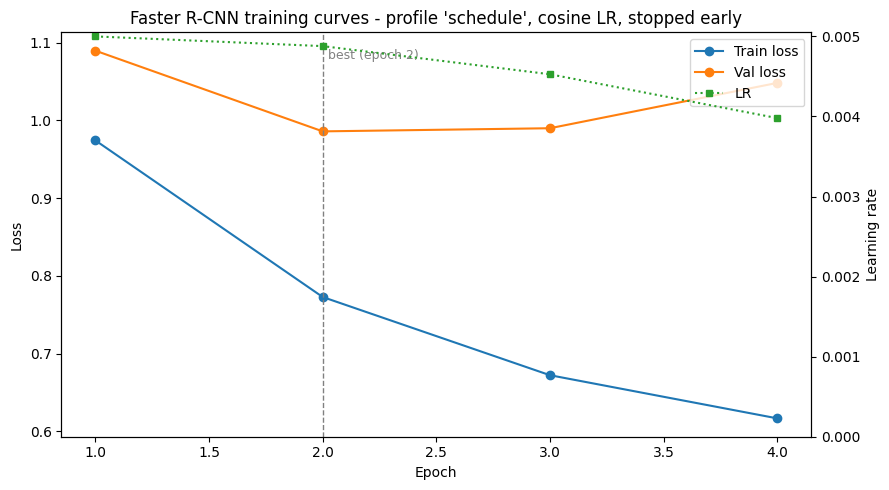

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df["epoch"], history_df["train_loss"], label="Train loss", marker="o")
ax.plot(history_df["epoch"], history_df["val_loss"], label="Val loss", marker="o")
ax.axvline(best_epoch, color="grey", linestyle="--", linewidth=1)
ax.annotate(f"best (epoch {best_epoch})", xy=(best_epoch, ax.get_ylim()[1]),
            xytext=(4, -12), textcoords="offset points", color="grey", fontsize=9, va="top")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

lr_ax = ax.twinx()
lr_ax.plot(history_df["epoch"], history_df["lr"], label="LR", color="tab:green",
           linestyle=":", marker="s", markersize=4)
lr_ax.set_ylabel("Learning rate")
lr_ax.set_ylim(bottom=0)

lines = ax.get_lines()[:2] + lr_ax.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc="upper right")
ax.set_title(f"Faster R-CNN training curves - profile '{RUN_PROFILE}', cosine LR"
             + (", stopped early" if stopped_early else ""))
plt.tight_layout()
plt.show()

## Test-Set mAP and Inference Latency

Loads the best (lowest val-loss) checkpoint and computes COCO-style mAP on the held-out test
split — the same metric family the YOLO challenger reports, so the two models are comparable
head-to-head.

**Latency is measured here too**, because a "challenger" claim that ignores cost is only half an
answer: two-stage detectors are typically several times slower than YOLO, and if deployment cost is
part of the evaluation then mAP alone cannot settle it. The measurement is deliberately narrow and
stated as such:

- **Batch size 1, `eval()` mode**, which is the deployment-shaped case (batching favours the
  two-stage model and would flatter it here).
- **`torch.cuda.synchronize()` on both sides of each forward pass.** CUDA kernels launch
  asynchronously, so timing without synchronizing measures queueing, not compute — usually off by
  an order of magnitude.
- **Warm-up images discarded.** The first few forwards pay cuDNN autotuning and allocator warm-up.
- **Model-only, not end-to-end.** The image is already decoded and on the GPU, so this excludes
  disk read and JPEG decode. It covers the resize, backbone, RPN, heads and NMS — the same span
  YOLO's reported inference time covers, which is what makes the two comparable.
- **Reported with its resolution.** Latency and mAP both move with `min_size`/`max_size`, so a
  latency number quoted without one is not comparable to anything.

In [14]:
best_path = resolve_checkpoint(BEST_NAME)  # local copy if this session trained, else the Drive copy
assert best_path is not None, (
    f"No {BEST_NAME} in {LOCAL_CHECKPOINT_DIR} or {DRIVE_CHECKPOINT_DIR} - train at least one epoch first."
)
print(f"Evaluating checkpoint: {best_path}")

model.load_state_dict(torch.load(best_path, map_location=device))
model.to(device)
model.eval()

metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        preds = model(images)

        preds = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets_cpu = [{k: v for k, v in t.items() if k in ("boxes", "labels")} for t in targets]

        metric.update(preds, targets_cpu)

results = metric.compute()
print(f"mAP@[0.5:0.95]: {results['map']:.4f}")
print(f"mAP@0.5: {results['map_50']:.4f}")
print(f"mAP@0.75: {results['map_75']:.4f}")
print(f"mAR@100: {results['mar_100']:.4f}")

# ---------------------------------------------------------------------------------------------
# Per-image inference latency
# ---------------------------------------------------------------------------------------------
LATENCY_WARMUP_N = 10
LATENCY_SAMPLE_N = 100

lat_rng = random.Random(SEED)
n_needed = min(LATENCY_WARMUP_N + LATENCY_SAMPLE_N, len(test_dataset))
latency_indices = lat_rng.sample(range(len(test_dataset)), n_needed)

latencies_ms = []
with torch.no_grad():
    for i, idx in enumerate(latency_indices):
        img, _ = test_dataset[idx]
        img = img.to(device)  # transfer excluded from the timed region - this is model latency
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        model([img])
        if device.type == "cuda":
            torch.cuda.synchronize()  # CUDA is async; without this we would time the launch, not the work
        dt_ms = (time.perf_counter() - t0) * 1000
        if i >= LATENCY_WARMUP_N:  # discard warm-up (cuDNN autotune, allocator growth)
            latencies_ms.append(dt_ms)

latency = pd.Series(latencies_ms)
print(f"\nInference latency ({len(latency)} images, batch size 1, {device.type}, "
      f"min_size={MIN_SIZE}/max_size={MAX_SIZE}):")
print(f"  mean {latency.mean():.1f} ms | median {latency.median():.1f} ms | "
      f"p90 {latency.quantile(0.90):.1f} ms | max {latency.max():.1f} ms")
print(f"  throughput: {1000 / latency.mean():.1f} img/s single-stream")
print("  (model forward + NMS only; excludes disk read and JPEG decode)")

Evaluating checkpoint: /content/checkpoints/fasterrcnn_schedule/fasterrcnn_best.pt
mAP@[0.5:0.95]: 0.0719
mAP@0.5: 0.1558
mAP@0.75: 0.0536
mAR@100: 0.1447

Inference latency (100 images, batch size 1, cuda, min_size=512/max_size=800):
  mean 92.4 ms | median 90.0 ms | p90 104.9 ms | max 115.3 ms
  throughput: 10.8 img/s single-stream
  (model forward + NMS only; excludes disk read and JPEG decode)


### Per-Class AP, Split Head vs. Tail

The baseline's summary number averaged two very different behaviours: a handful of visually
distinctive, well-represented classes that the model genuinely detects, and a long tail sitting at
exactly zero. Reporting a single mean lets the tail's zeros silently set the headline while hiding
which half moved.

So the table below also splits the evaluated classes at the **median training frequency** — a
data-driven cut rather than an arbitrary instance-count threshold — and reports mean AP for each
half separately. That split is what makes the class-balanced sampler falsifiable: if it worked, tail
mean AP rises and the count of AP = 0 classes falls; if it went too far, head mean AP drops at the
same time, and `OVERSAMPLE_POWER` should come down.

In [15]:
evaluated_class_ids = results["classes"].tolist()  # 1-indexed model labels; 0 is background
per_class_ap = pd.DataFrame({
    "class": [CLASS_NAMES[i - 1] for i in evaluated_class_ids],
    "AP@[0.5:0.95]": results["map_per_class"].tolist(),
    # Training frequency = images containing the class, over the full training split (before
    # subsetting), so head/tail membership is a property of the dataset and stays comparable across
    # run profiles. Keyed off the class id rather than the name - names are not guaranteed unique.
    "train_images": [class_counts.get(i - 1, 0) for i in evaluated_class_ids],
})

# torchmetrics reports -1 for a class it could not evaluate (no ground-truth boxes AND no
# predictions for it anywhere in the test split). That means "not measured", not "an AP of -1",
# so those rows are separated out rather than sorted to the bottom of the table as though they
# were the worst scores - and they must never be averaged into a summary.
not_evaluated = per_class_ap[per_class_ap["AP@[0.5:0.95]"] < 0]
scored = per_class_ap[per_class_ap["AP@[0.5:0.95]"] >= 0].copy()
scored = scored.sort_values("AP@[0.5:0.95]", ascending=False).reset_index(drop=True)

detected = scored[scored["AP@[0.5:0.95]"] > 0]
print(f"{len(CLASS_NAMES)} classes in the taxonomy")
print(f"  {len(scored)} evaluated on the test split; {len(not_evaluated)} not evaluated "
      f"(absent from both predictions and ground truth)")
print(f"  {len(detected)} with AP > 0; {len(scored) - len(detected)} at AP = 0")
if len(detected):
    print(f"  among AP > 0: mean {detected['AP@[0.5:0.95]'].mean():.3f}, "
          f"median {detected['AP@[0.5:0.95]'].median():.3f}, "
          f"max {detected['AP@[0.5:0.95]'].max():.3f}")

# Head vs tail, split at the median training frequency across evaluated classes.
tail_threshold = scored["train_images"].median()
scored["group"] = np.where(scored["train_images"] < tail_threshold, "tail", "head")
print(f"\nHead/tail split at the median training frequency ({tail_threshold:.0f} images):")
for group in ("head", "tail"):
    g = scored[scored["group"] == group]
    if not len(g):
        continue
    zeros = (g["AP@[0.5:0.95]"] == 0).sum()
    print(f"  {group:>4}: {len(g):3d} classes | mean AP {g['AP@[0.5:0.95]'].mean():.3f} | "
          f"median {g['AP@[0.5:0.95]'].median():.3f} | {zeros:3d} at AP = 0 "
          f"| train images {g['train_images'].min():,}-{g['train_images'].max():,}")

# The headline mAP is held down mostly by the long tail of zeros, so show that shape explicitly
# rather than leaving a reader to infer it from a 127-row table.
bins = [-0.001, 0.0, 0.05, 0.15, 0.30, 1.0]
labels = ["AP = 0", "0 - 0.05", "0.05 - 0.15", "0.15 - 0.30", "> 0.30"]
print("\nAP distribution across evaluated classes:")
counts = pd.cut(scored["AP@[0.5:0.95]"], bins=bins, labels=labels).value_counts().sort_index()
for label, count in counts.items():
    print(f"  {label:>12}: {count:3d} classes")

if len(not_evaluated):
    print(f"\nNot evaluated ({len(not_evaluated)}): {', '.join(sorted(not_evaluated['class']))}")

scored.style.hide(axis="index").background_gradient(subset=["AP@[0.5:0.95]"], cmap="Blues")

148 classes in the taxonomy
  102 evaluated on the test split; 32 not evaluated (absent from both predictions and ground truth)
  62 with AP > 0; 40 at AP = 0
  among AP > 0: mean 0.118, median 0.076, max 0.525

Head/tail split at the median training frequency (114 images):
  head:  51 classes | mean AP 0.072 | median 0.022 |  11 at AP = 0 | train images 119-2,739
  tail:  51 classes | mean AP 0.072 | median 0.000 |  29 at AP = 0 | train images 4-110

AP distribution across evaluated classes:
        AP = 0:  40 classes
      0 - 0.05:  24 classes
   0.05 - 0.15:  20 classes
   0.15 - 0.30:  11 classes
        > 0.30:   7 classes

Not evaluated (32): akabare khursani, bamboo shoots, black beans, black lentils, cassava, chayote, chicken gizzards, cinnamon, crab meat, date, garden cress, garden peas, green lentils, green soyabean, ice, jack fruit, milk, noodle, okra, olive oil, palak, pointed gourd, prune, red lentils, sausage, seaweed, snake gourd, soyabean, sponge gourd, stinging nettl

class,AP@[0.5:0.95],train_images,group
minced meat,0.525248,8,tail
bread,0.435974,162,head
beef,0.400000,18,tail
kimchi,0.350000,66,tail
raspberry,0.330024,76,tail
egg,0.306717,293,head
tori ko saag,0.300000,15,tail
green mint,0.269948,170,head
soy sauce,0.250000,24,tail
orange,0.245001,2289,head


### Comparison Against the Baseline Run

The baseline column is the recorded result of `fasterrcnn_food_detection.ipynb` (fixed 10 epochs,
`StepLR(step_size=3)`, uniform shuffling, 32.5% subset at 512/800, best checkpoint at epoch 4).
Those numbers are hard-coded here because that run is finished; only the right-hand column is
computed from this session.

Read the deltas against the profile you ran. Under `schedule`, the data and resolution are identical
to the baseline, so any movement is attributable to the schedule, stopping, and sampling changes
alone. Under `full_data` or `full_res`, one further axis has moved and the delta mixes two causes —
which is why the profiles do not move both at once.

In [16]:
BASELINE_METRICS = {  # recorded results from fasterrcnn_food_detection.ipynb - do not edit
    "mAP@[0.5:0.95]": 0.0785,
    "mAP@0.5": 0.1594,
    "mAP@0.75": 0.0675,
    "mAR@100": 0.1444,
}
BASELINE_EPOCHS, BASELINE_BEST_EPOCH, BASELINE_HOURS = 10, 4, 2.38

this_run_metrics = {
    "mAP@[0.5:0.95]": float(results["map"]),
    "mAP@0.5": float(results["map_50"]),
    "mAP@0.75": float(results["map_75"]),
    "mAR@100": float(results["mar_100"]),
}

this_col = f"this run ({RUN_PROFILE})"
comparison = pd.DataFrame({"baseline": BASELINE_METRICS, this_col: this_run_metrics})
comparison["delta"] = comparison[this_col] - comparison["baseline"]
comparison["delta %"] = 100 * comparison["delta"] / comparison["baseline"]

print("Baseline: 32.5% subset @ 512/800, StepLR, uniform sampling, fixed 10 epochs")
print(f"This run: {TRAIN_SUBSET_FRAC:.0%} subset @ {MIN_SIZE}/{MAX_SIZE}, cosine LR, "
      f"oversample power {OVERSAMPLE_POWER}, early stop patience {EARLY_STOP_PATIENCE}")
print(f"\nEpochs run : {BASELINE_EPOCHS} (best {BASELINE_BEST_EPOCH}) -> "
      f"{trained_epochs} (best {best_epoch})")
print(f"Train hours: {BASELINE_HOURS:.2f} -> {total_hours:.2f} "
      f"({total_hours - BASELINE_HOURS:+.2f} h)")
print("\nThe baseline reported no latency number, so there is nothing to diff it against.")
comparison.style.format({"baseline": "{:.4f}", this_col: "{:.4f}",
                         "delta": "{:+.4f}", "delta %": "{:+.1f}%"})

Baseline: 32.5% subset @ 512/800, StepLR, uniform sampling, fixed 10 epochs
This run: 30% subset @ 512/800, cosine LR, oversample power 0.5, early stop patience 2

Epochs run : 10 (best 4) -> 4 (best 2)
Train hours: 2.38 -> 0.95 (-1.43 h)

The baseline reported no latency number, so there is nothing to diff it against.


,baseline,this run (schedule),delta,delta %
mAP@[0.5:0.95],0.0785,0.0719,-0.0066,-8.4%
mAP@0.5,0.1594,0.1558,-0.0036,-2.2%
mAP@0.75,0.0675,0.0536,-0.0139,-20.6%
mAR@100,0.1444,0.1447,+0.0003,+0.2%


## Sample Predictions

Ground truth in green, model predictions (score >= 0.5) in red, on a random sample of test
images.


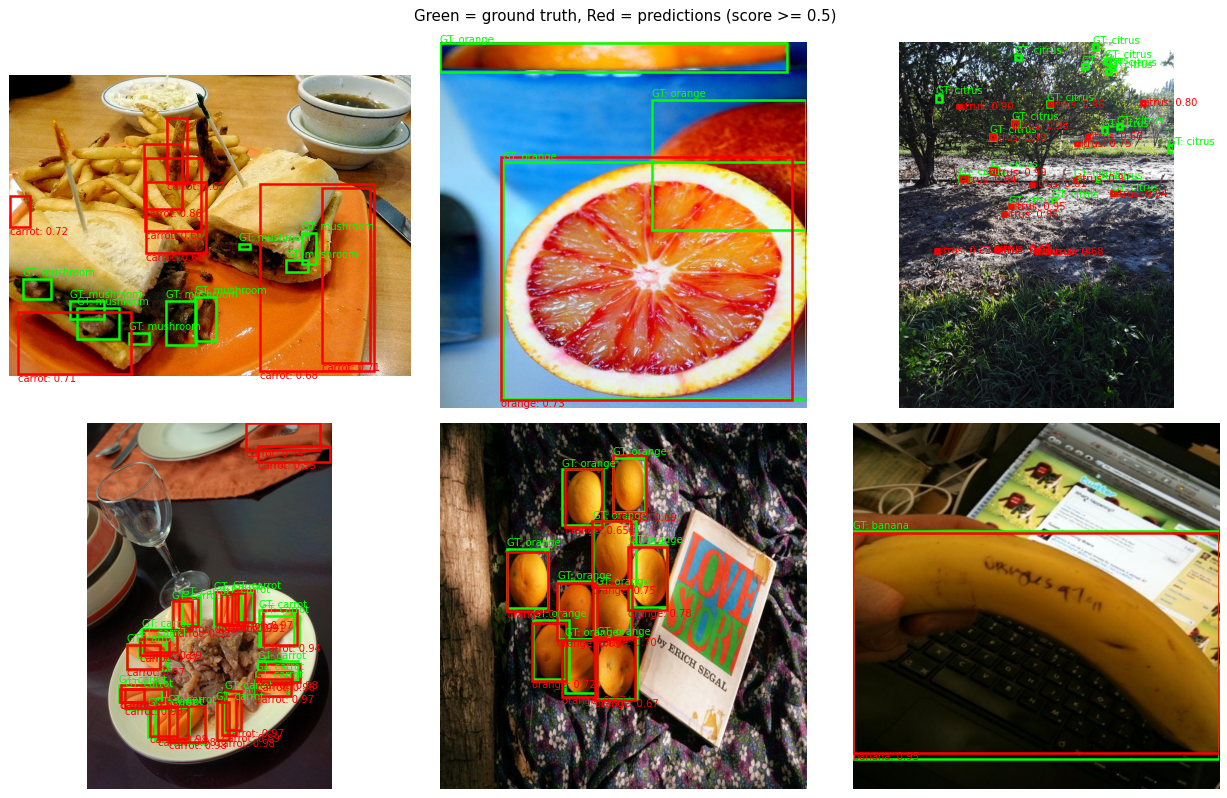

In [17]:
def draw_predictions(ax, image_tensor, target, prediction=None, score_thresh=0.5):
    img = image_tensor.permute(1, 2, 0).numpy()
    ax.imshow(img)

    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 5, 0), f"GT: {CLASS_NAMES[int(label) - 1]}", color="lime", fontsize=8)

    if prediction is not None:
        keep = prediction["scores"] >= score_thresh
        for box, label, score in zip(prediction["boxes"][keep], prediction["labels"][keep], prediction["scores"][keep]):
            x1, y1, x2, y2 = box.tolist()
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="red", facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y2 + 12, f"{CLASS_NAMES[int(label) - 1]}: {score:.2f}", color="red", fontsize=8)

    ax.axis("off")


model.eval()
sample_indices = random.sample(range(len(test_dataset)), min(6, len(test_dataset)))

# figsize/dpi kept modest deliberately: at (16, 10) this single figure embedded ~2.9 MB of PNG
# into the .ipynb, which dominated the file size in git. Raise dpi if you need a print-quality
# version for the report.
fig, axes = plt.subplots(2, 3, figsize=(14, 9), dpi=90)
axes = axes.flatten()

with torch.no_grad():
    for ax, idx in zip(axes, sample_indices):
        img, target = test_dataset[idx]
        pred = model([img.to(device)])[0]
        pred = {k: v.cpu() for k, v in pred.items()}
        draw_predictions(ax, img, target, pred)

plt.suptitle("Green = ground truth, Red = predictions (score >= 0.5)")
plt.tight_layout()
plt.show()


## How to Read This Run

No results are asserted here — this notebook has not been run. What follows is what each change is
supposed to move, and what would say it did not work, so the write-up can be honest either way.

**Cosine LR + early stopping.** Expect the run to stop somewhere before epoch 10 and the training
loss to keep descending until it does, rather than flatlining at ~0.50 for four epochs the way the
baseline's did (its LR was at 1/100th of base by epoch 7). Check the LR trace on the curves plot.
*Falsified if:* val loss bottoms out at roughly the same epoch and value as the baseline's 0.8339 —
that would say the ceiling was data, not the schedule, and the next lever is `full_data`.

**Class-balanced sampling.** Expect tail mean AP up and fewer classes at exactly AP = 0 in the
head/tail table. *Falsified if:* head mean AP falls by more than the tail gains — that is
oversampling past the useful point, and `OVERSAMPLE_POWER` should drop toward 0.25. Setting it to
`0.0` exactly reproduces the baseline's sampling, which is the control if the result looks
ambiguous.

**Profiles.** `full_data` is the more informative of the two remaining levers, because the baseline
trained on under a third of the data and its long-tail failure is at least partly a data-volume
problem rather than an architecture one. `full_res` answers a narrower question — how much of the
small-object weakness the 512/800 choice caused — and matters most read against the EDA notebook's
box-size distribution.

**What still bounds any result from this notebook.** Whichever profile runs, only one of the two
compute axes has moved, so a remaining gap against YOLO still reflects architecture *plus* a
constrained budget, not architecture alone. The honest framing remains that this is a
Colab-feasible Faster R-CNN, now with a schedule and a sampler that are no longer obviously
leaving performance on the table — not a fully tuned one.

**Left for a later run.** Test-time augmentation, a stronger augmentation policy during training
(the dataset pipeline here does horizontal flips only), `trainable_backbone_layers` sweeps, and
score-threshold calibration per class. None of these are worth doing before the data-volume
question is settled.